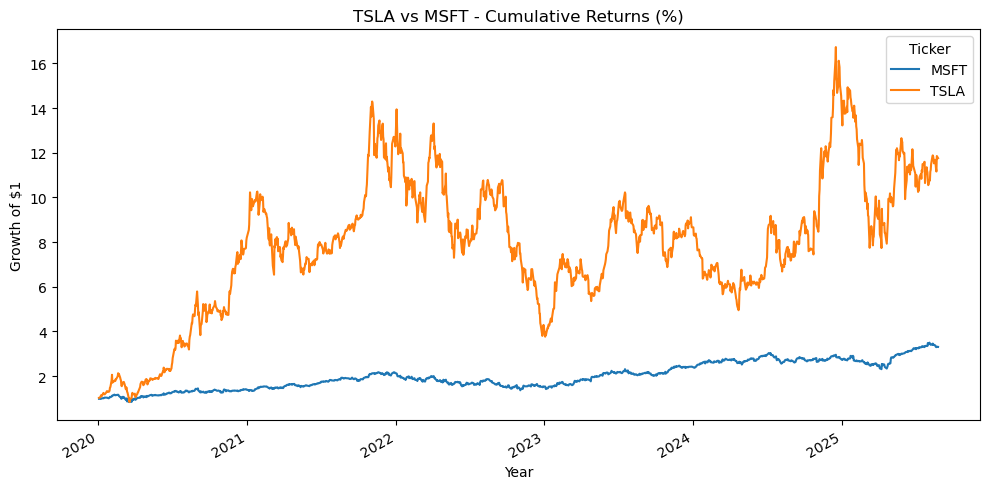

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

#Import Tesla and Microsoft data 
df = yf.download(["TSLA", "MSFT"], start="2020-01-01", auto_adjust=True, progress=False)

#Daily returns
prices = df["Close"].dropna(how="any")
rets = prices.pct_change().dropna()

#Cumulative Returns
cum = (1 +rets).cumprod()

#Plot the cumulative returns
plt.figure(figsize=(10, 5))
cum.plot(ax=plt.gca())
plt.title("TSLA vs MSFT - Cumulative Returns (Growth of $1")
plt.xlabel("Year")
plt.ylabel("Growth of $1")
plt.tight_layout()
plt.show()


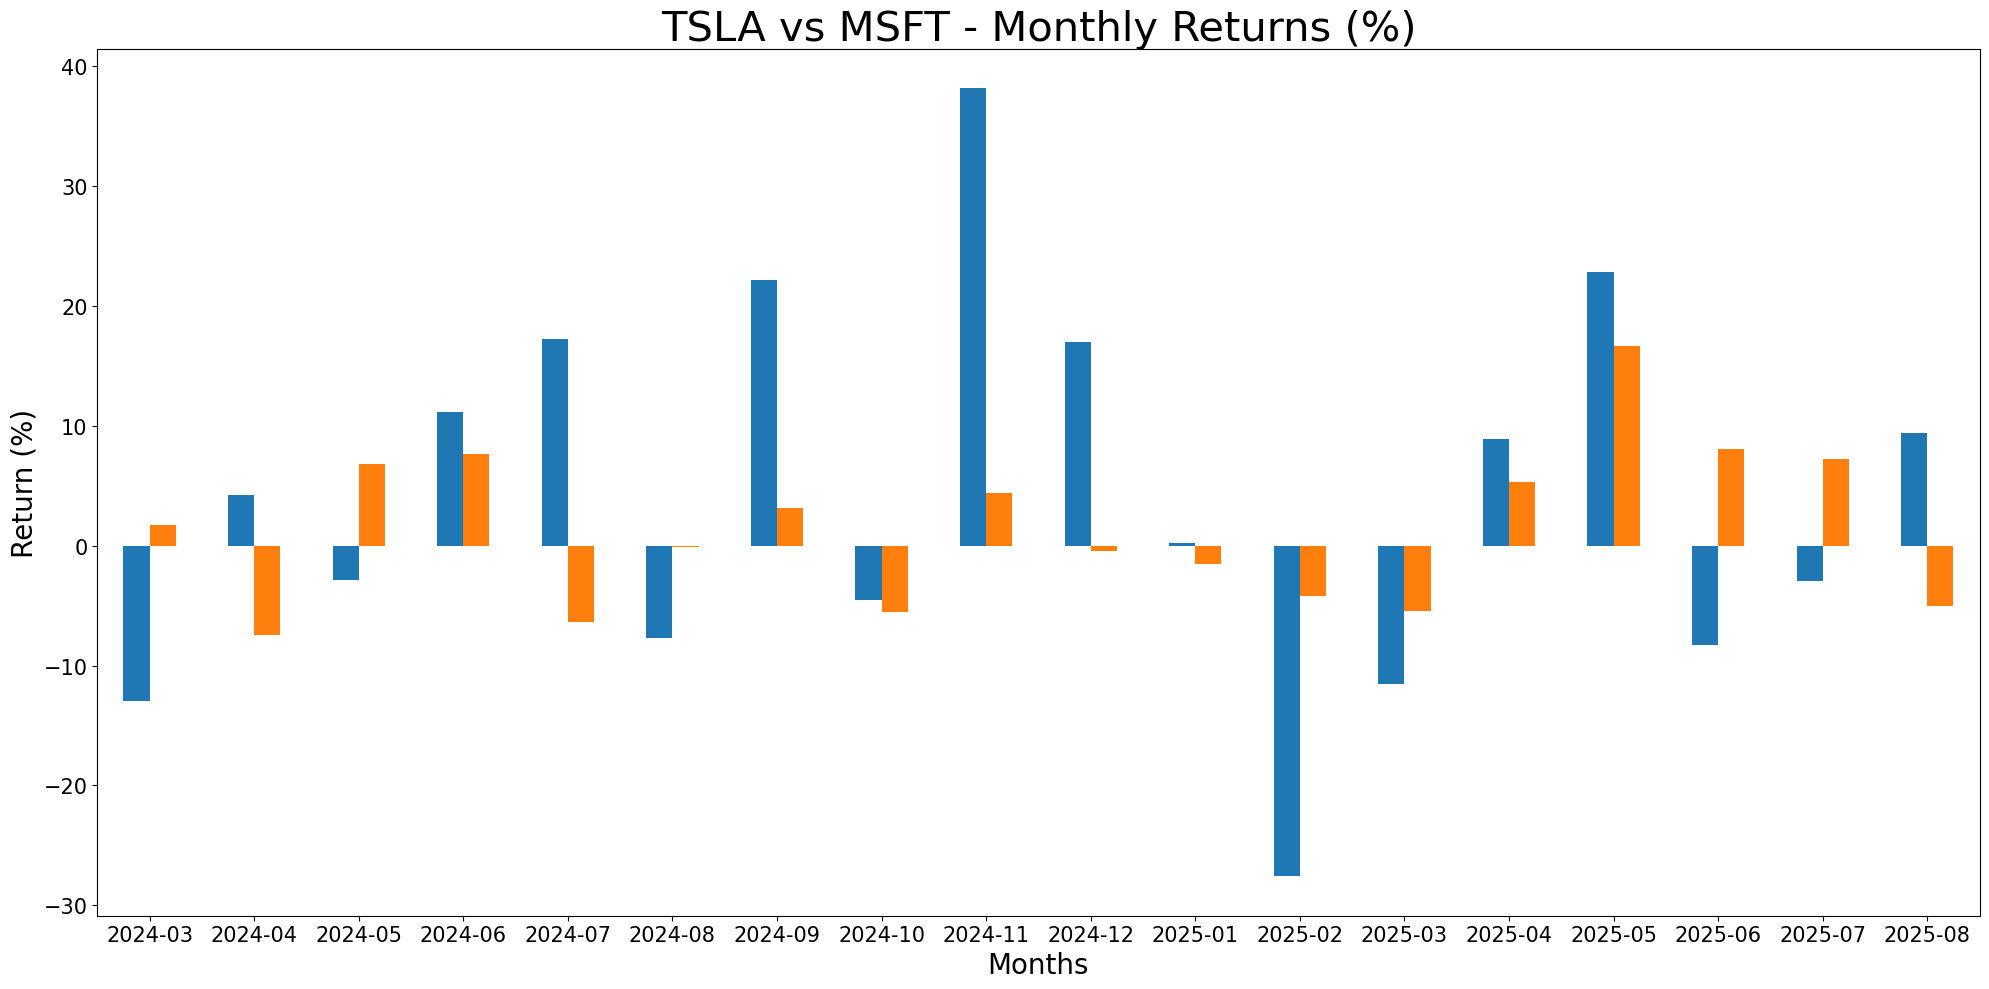

In [34]:
#Monthly returns
monthly = (1 + rets).resample("ME").prod() - 1

#Plot chart
m = monthly[["TSLA", "MSFT"]].tail(18).mul(100).copy()
m.index = m.index.to_period("M").astype(str)

ax = m.plot(kind="bar", rot=0, legend=False, figsize=(20, 10), fontsize=15)
ax.set_title("TSLA vs MSFT - Monthly Returns (%)", fontsize=(30))
ax.set_xlabel("Months", fontsize=(20))
ax.set_ylabel("Return (%)", fontsize=(20))
plt.tight_layout()
plt.show()



Annualised Volatility (Overall):
Ticker
MSFT    0.301
TSLA    0.676
dtype: float64


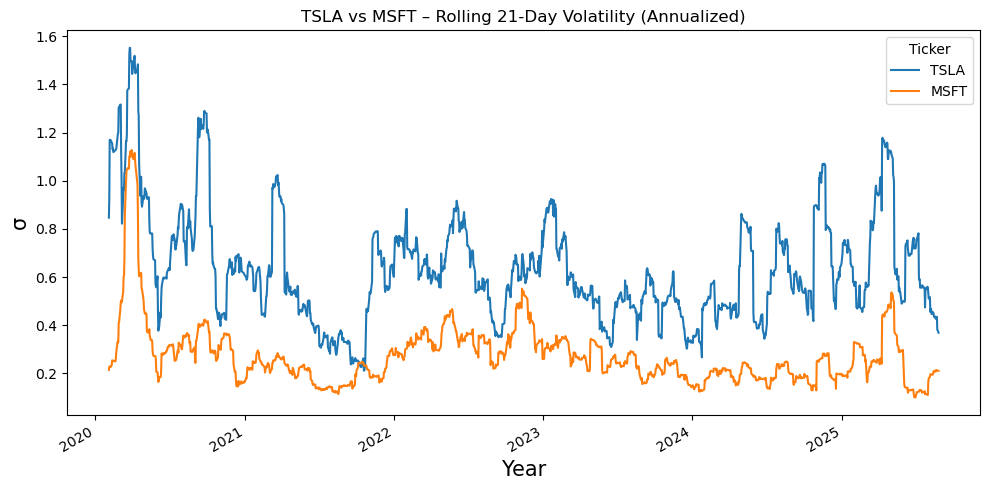

In [49]:
#Volatility
overall_vol = (rets.std() * np.sqrt(252)).round(3)  print("\nAnnualised Volatility (Overall):")
print(overall_vol)

#Rolling 21 day volatility
rolling_vol = rets.rolling(21).std() * np.sqrt(252)
ax = rolling_vol = rolling_vol[["TSLA", "MSFT"]].dropna().plot(figsize=(10, 5))
ax.set_title("TSLA vs MSFT – Rolling 21-Day Volatility (Annualized)")
ax.set_ylabel("σ", fontsize=(15))
ax.set_xlabel("Year", fontsize=(15))   
plt.tight_layout()
plt.show()

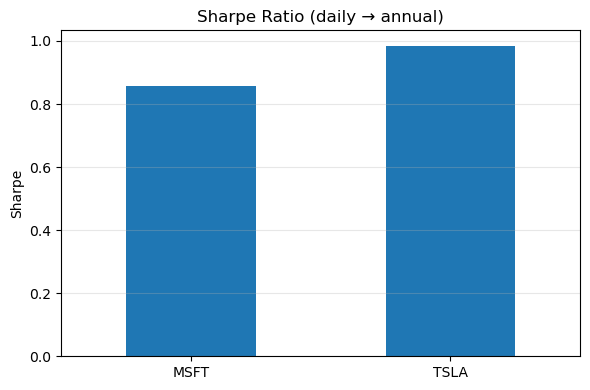

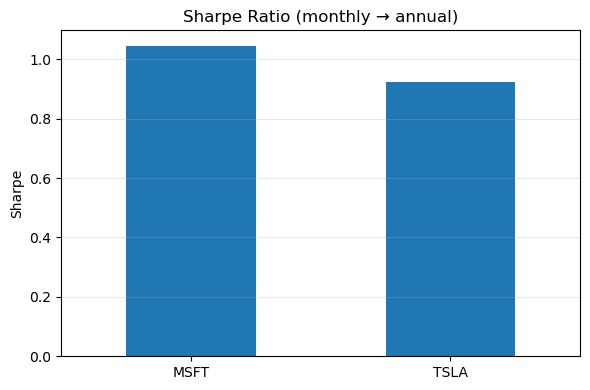

In [53]:
#Sharpe daily returns
sharpe_daily = (rets.mean() /  rets.std()) * np.sqrt(252)
ax = sharpe_daily.plot(kind="bar", figsize=(6,4), rot=0)   
ax.set_title("Sharpe Ratio (daily → annual)")
ax.set_ylabel("Sharpe"); ax.set_xlabel("")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

#Monthly Return
monthly = (1 + rets).resample("ME").prod() - 1

#Sharpe Monthly Returns
sharpe_monthly = (monthly.mean() / monthly.std()) * np.sqrt(12)
ax = sharpe_monthly.plot(kind="bar", figsize=(6,4), rot=0)
ax.set_title("Sharpe Ratio (monthly → annual)")
ax.set_ylabel("Sharpe"); ax.set_xlabel("")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
